In [1]:
import sys
sys.path.insert(0, '/Users/lyuan13/Downloads/pca_sphere_projection/')
import pca_sphere_projection.core as pc

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from scipy.spatial.transform import Rotation as R
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, spearmanr
import matplotlib.cm as cm
import statsmodels.stats.multitest as smm

In [2]:
def cartesian_to_spherical(x, y, z):
    longitude = np.arctan2(y, x)
    latitude = np.arcsin(z / np.sqrt(x**2 + y**2 + z**2))
    return longitude, latitude

In [3]:
data = pd.read_csv('planaria_pca.csv')
centroid = data[data['celltype'] == 'neoblast 1'][['PC1', 'PC2', 'PC3']].mean().values

data = pc.align_to_north_pole(data, pcs_columns=['PC1', 'PC2', 'PC3'], cluster_column='cluster', root_node=centroid)
data = pc.apply_euler_rotation(data, pcs_columns=['PC1', 'PC2', 'PC3'], rotation_angles=[80,50,50], degrees=True)

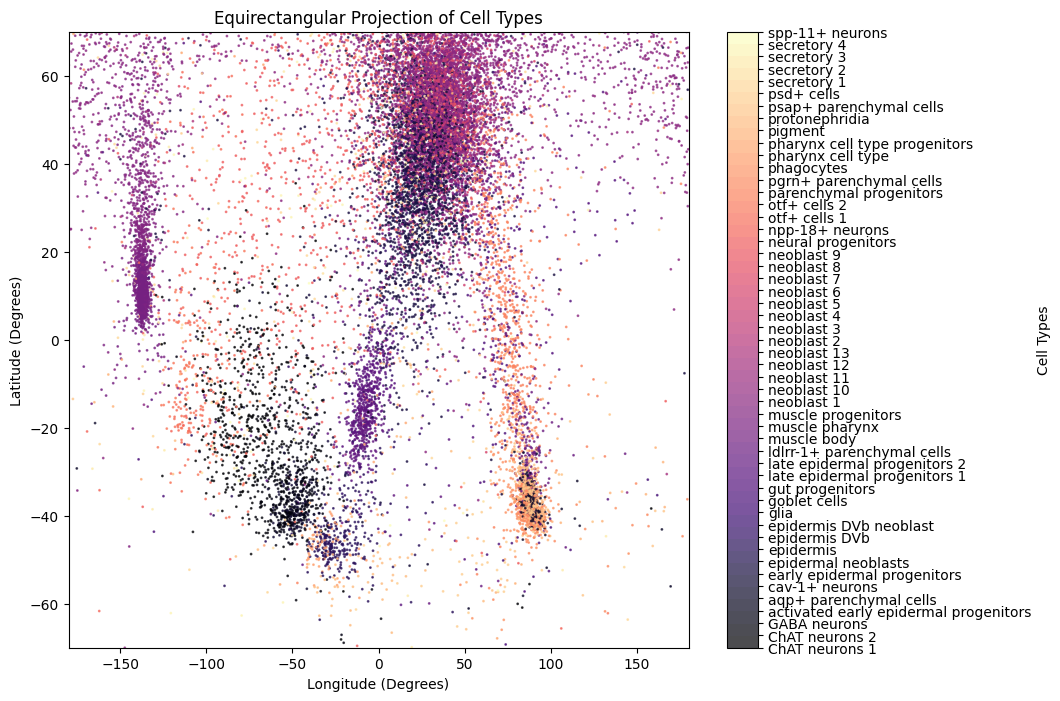

In [4]:
pc.equirectangular_projection(data, 
                              pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                              cluster_column='celltype', 
                              categories=None, 
                              selected_celltypes=None, 
                              colormap='magma', 
                              figsize=(10, 8), 
                              point_size=1, 
                              alpha=0.7, 
                              xlim=(-180, 180), 
                              ylim=(-70, 70))

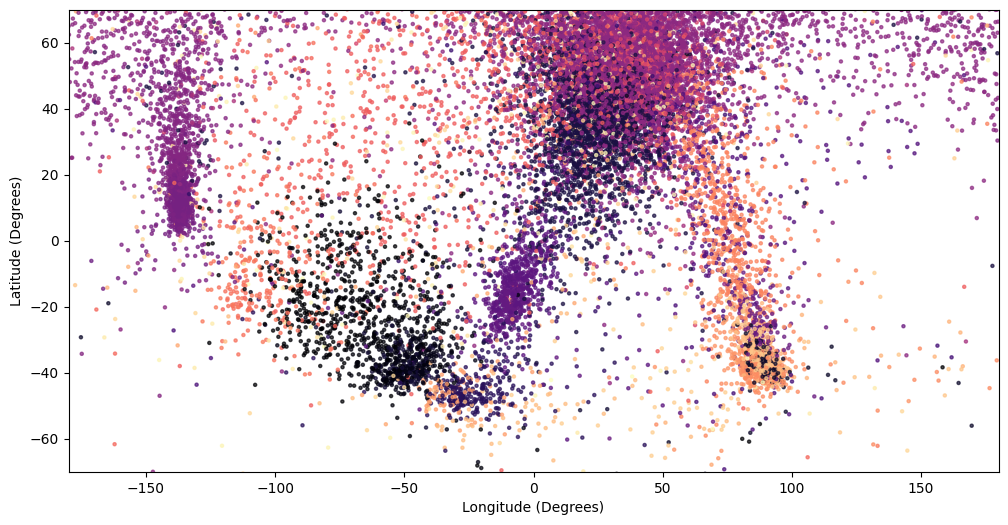

In [5]:
longitudes, latitudes = cartesian_to_spherical(data['rotated_PC1'], data['rotated_PC2'], data['rotated_PC3'])
longitudes = np.degrees(longitudes)
latitudes = np.degrees(latitudes)

data['Longitude'] = longitudes
data['Latitude'] = latitudes

celltypes = data['celltype'].astype('category').cat.codes
unique_celltypes = data['celltype'].unique() 
colormap = cm.get_cmap('magma', len(unique_celltypes))

fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(data['Longitude'], data['Latitude'], c=celltypes, cmap=colormap,  s=5, alpha=0.7)
ax.set_xlabel('Longitude (Degrees)')
ax.set_ylabel('Latitude (Degrees)')
ax.set_xlim(-180, 180)
ax.set_ylim(-70, 70)

ax.grid(False)
plt.show()

/Users/lyuan13/Downloads/pca_sphere_projection\pca_sphere_projection\core.py:253: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


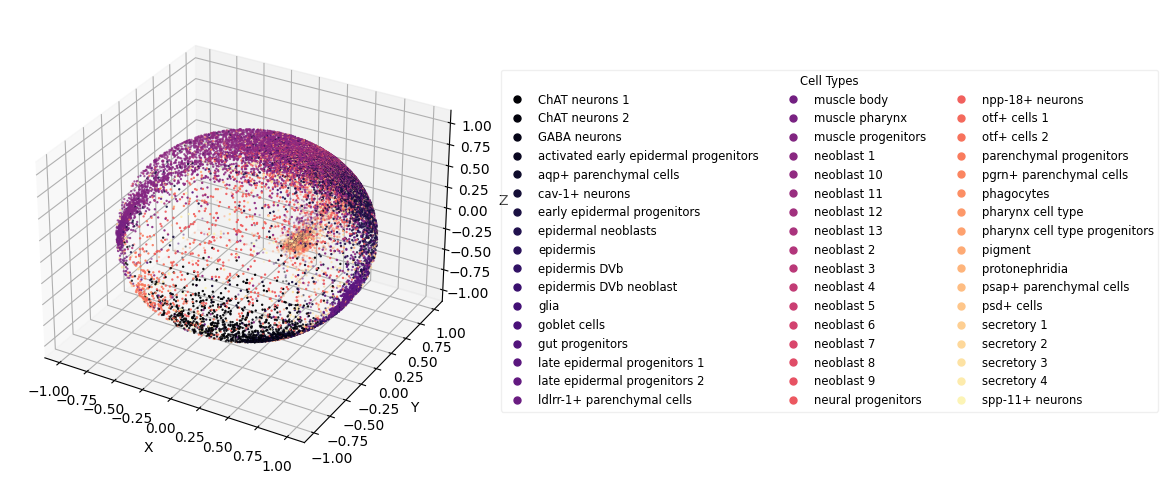

In [6]:
pc.visualize_globe( data, 
                    pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                    cluster_column='celltype', 
                    colormap='magma', 
                    point_size=0.5, 
                    interactive=False, 
                    output_html=None, 
                    figsize=(6, 6), 
                    legend_columns=3)

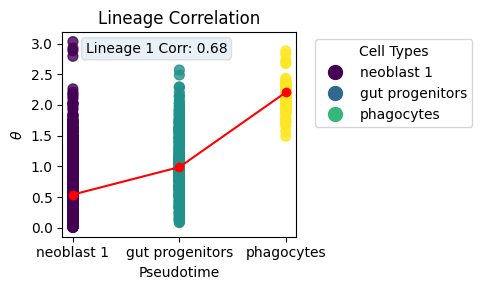

In [7]:
pc.visualize_lineage_correlation( data, 
                                  cell_types_lineage1=['neoblast 1', 'gut progenitors', 'phagocytes'], 
                                  cell_types_lineage2=None, 
                                  pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                                  cluster_column='celltype', 
                                  colormap='viridis', 
                                  figsize=(5, 3), 
                                  annotate=True)

In [8]:
######################################
# Customized plotting for aesthetics #
######################################

cell_types_of_interest = [
    'neoblast 1', 
    'epidermal neoblasts', 
    'early epidermal progenitors', 
    'late epidermal progenitors 1', 
    'late epidermal progenitors 2', 
    'epidermis'
]
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()
filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

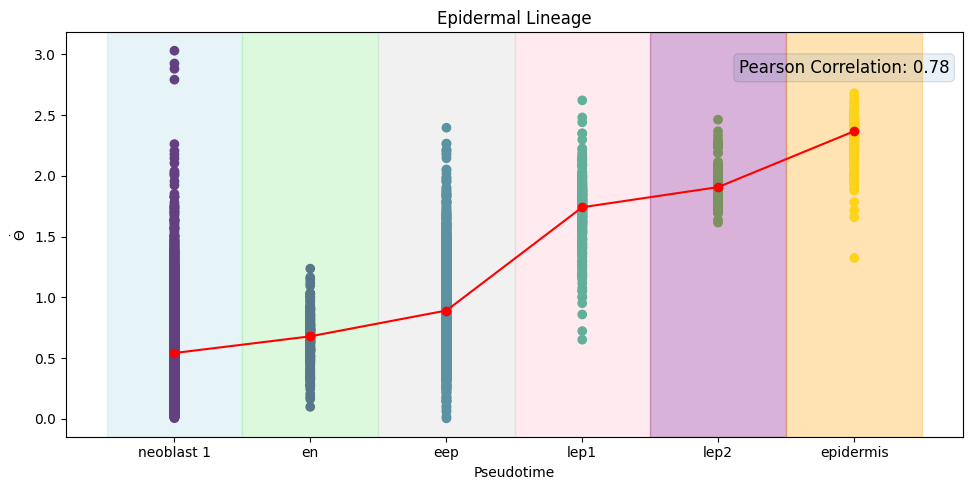

In [9]:
stages = {
    'neoblast 1': (0, 1.66),
    'epidermal neoblasts': (1.66, 3.33),
    'early epidermal progenitors': (3.33, 5),
    'late epidermal progenitors 1': (5, 6.66),
    'late epidermal progenitors 2': (6.66, 8.33),
    'epidermis': (8.33, 10)
}

category_scale = {
    'neoblast 1': 0.83,  # Average of 0 and 1.66
    'epidermal neoblasts': 2.495,  # Average of 1.66 and 3.33
    'early epidermal progenitors': 4.165,  # Average of 3.33 and 5
    'late epidermal progenitors 1': 5.83,  # Average of 5 and 6.66
    'late epidermal progenitors 2': 7.495,  # Average of 6.66 and 8.33
    'epidermis': 9.165  # Average of 8.33 and 10
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])


fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis', label='Theta vs Pseudotime')

ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'en', 'eep', 'lep1', 'lep2', 'epidermis']))

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')


colors = ['lightblue', 'lightgreen', 'lightgrey', 'pink', 'purple', 'orange']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Epidermal Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [10]:
cell_types_of_interest = ['neoblast 1', 'gut progenitors', 'phagocytes']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()


filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)
filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

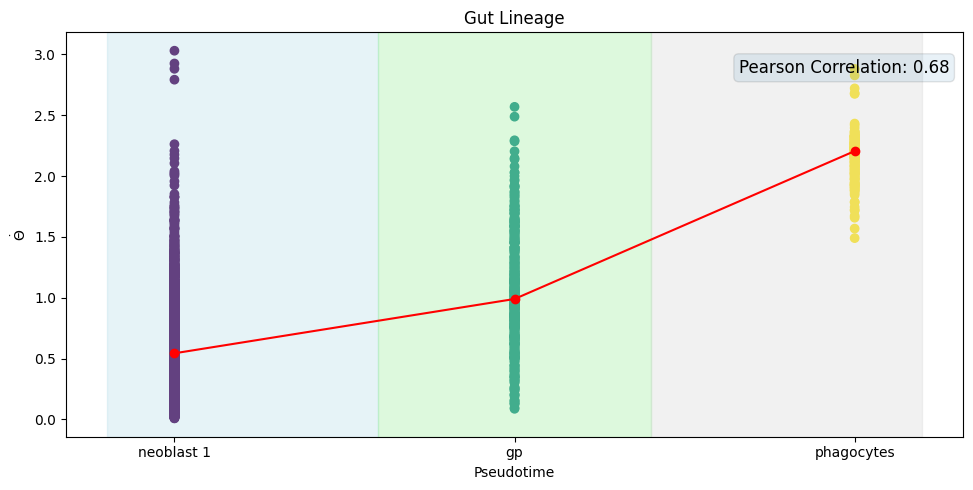

In [11]:
stages = {
    'neoblast 1': (0, 3.33),       
    'gut progenitors': (3.33, 6.67), 
    'phagocytes': (6.67, 10)        
}

category_scale = {
    'neoblast 1': 0.83,  
    'gut progenitors': 5,  
    'phagocytes': 9.17,  
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])


fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')

ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'gp', 'phagocytes']))
medians = filtered_data.groupby('celltype')['theta'].median() 
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['lightblue', 'lightgreen', 'lightgrey']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Gut Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [12]:
cell_types_of_interest = ['neoblast 1', 'muscle progenitors', 'muscle body', 'muscle pharynx']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

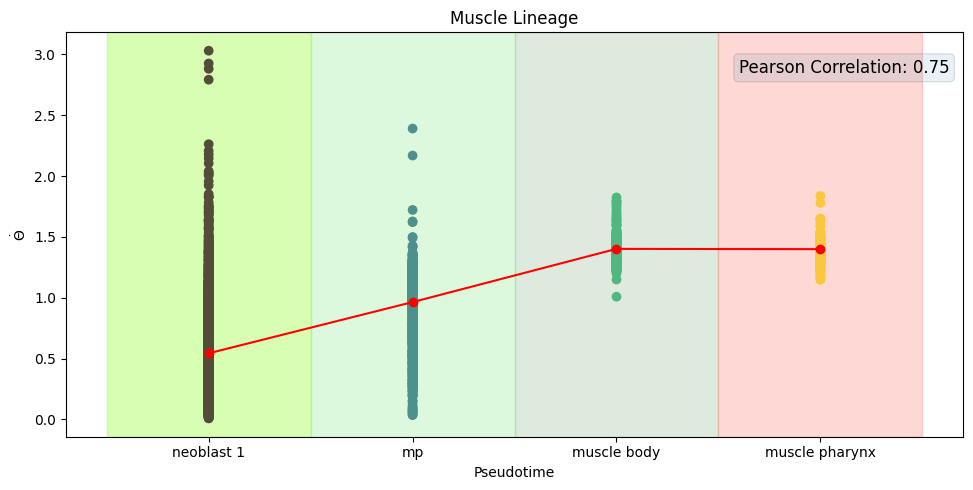

In [13]:
stages = {
    'neoblast 1': (0, 2.5),          
    'muscle progenitors': (2.5, 5),   
    'muscle body': (5, 7.5),          
    'muscle pharynx': (7.5, 10)     
}

category_scale = {
    'neoblast 1': 1.25,  
    'muscle progenitors': 3.75,  
    'muscle body': 6.25,  
    'muscle pharynx': 8.75  
}


filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')
ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'mp', 'muscle body', 'muscle pharynx']))

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['lawngreen', 'lightgreen', 'darkseagreen', 'salmon']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Muscle Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [14]:
cell_types_of_interest = ['neoblast 1', 'parenchymal progenitors', 'ldlrr-1+ parenchymal cells', 'pgrn+ parenchymal cells', 'glia']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

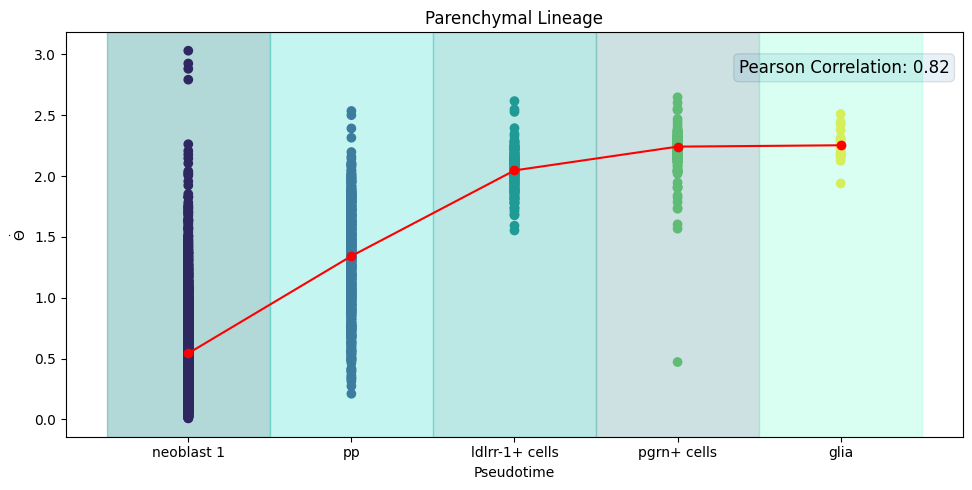

In [15]:
stages = {
    'neoblast 1': (0, 2),                     
    'parenchymal progenitors': (2, 4),      
    'ldlrr-1+ parenchymal cells': (4, 6),    
    'pgrn+ parenchymal cells': (6, 8),       
    'glia': (8, 10)                         
}

category_scale = {
    'neoblast 1': 1,                         
    'parenchymal progenitors': 3,             
    'ldlrr-1+ parenchymal cells': 5,         
    'pgrn+ parenchymal cells': 7,             
    'glia': 9                                
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'] ,
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')
ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(list(['neoblast 1', 'pp', 'ldlrr-1+ cells', 'pgrn+ cells', 'glia']))

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['teal', 'turquoise', 'lightseagreen', 'cadetblue', 'aquamarine']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Parenchymal Lineage')
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

In [16]:
cell_types_of_interest = ['neoblast 1', 'neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2', 'GABA neurons', 'cav-1+ neurons']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

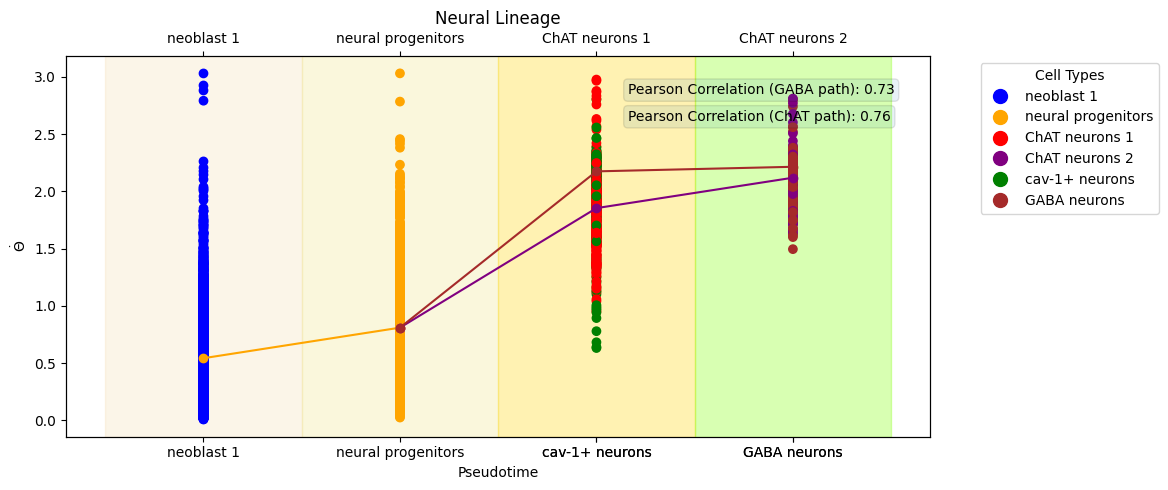

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

position_map = {'neoblast 1': 0, 'neural progenitors': 1, 'ChAT neurons 1': 2, 'ChAT neurons 2': 3,
                'cav-1+ neurons': 2, 'GABA neurons': 3}
filtered_data['position'] = filtered_data['celltype'].map(position_map)

gaba_path_data = filtered_data[filtered_data['celltype'].isin(['neoblast 1', 'neural progenitors', 'cav-1+ neurons', 'GABA neurons'])]
gaba_corr, _ = pearsonr(gaba_path_data['position'], gaba_path_data['theta'])
chat_path_data = filtered_data[filtered_data['celltype'].isin(['neoblast 1', 'neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'])]
chat_corr, _ = pearsonr(chat_path_data['position'], chat_path_data['theta'])

colors = ['wheat', 'khaki', 'gold', 'chartreuse']
ax.axvspan(0 - 0.5, 0 + 0.5, color=colors[0], alpha=0.3)
ax.axvspan(1 - 0.5, 1 + 0.5, color=colors[1], alpha=0.3)
ax.axvspan(2 - 0.5, 2 + 0.5, color=colors[2], alpha=0.3)
ax.axvspan(3 - 0.5, 3 + 0.5, color=colors[3], alpha=0.3)

color_map = {
    'neoblast 1': 'blue',
    'neural progenitors': 'orange',
    'ChAT neurons 1': 'red',
    'ChAT neurons 2': 'purple',
    'cav-1+ neurons': 'green',
    'GABA neurons': 'brown'
}

scatter = ax.scatter(
    filtered_data['position'], 
    filtered_data['theta'], 
    c=filtered_data['celltype'].map(color_map), 
    label='Theta vs Pseudotime'
)

def plot_valid_segments_custom_colors(data, groups, ax, color_map):
    for group in groups:
        group_data = data[data['celltype'].isin(group)]
        if group_data.empty:
            continue
        
        positions = [position_map[cat] for cat in group if cat in group_data['celltype'].unique()]
        medians = group_data.groupby('celltype')['theta'].median()
        valid_cats = [cat for cat in group if cat in medians.index]
        valid_medians = medians[valid_cats].values
        valid_positions = [position_map[cat] for cat in valid_cats]
        
        if len(valid_medians) > 1:
            ax.plot(valid_positions, valid_medians, 'o-', label=' to '.join(valid_cats), color=color_map[valid_cats[-1]])

groups = [
    ['neoblast 1', 'neural progenitors'],
    ['neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'],
    ['neural progenitors', 'cav-1+ neurons', 'GABA neurons']
]

plot_valid_segments_custom_colors(filtered_data, groups, ax, color_map)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
ax.set_title('Neural Lineage')

ax.set_xticks(list(position_map.values()))
ax.set_xticklabels(list(position_map.keys()))


ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(['neoblast 1', 'neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'])

ax.annotate(f'Pearson Correlation (GABA path): {gaba_corr:.2f}', xy=(0.65, 0.90), xycoords='axes fraction', fontsize=10, bbox=dict(boxstyle="round", alpha=0.1))
ax.annotate(f'Pearson Correlation (ChAT path): {chat_corr:.2f}', xy=(0.65, 0.83), xycoords='axes fraction', fontsize=10, bbox=dict(boxstyle="round", alpha=0.1))

handles = [plt.Line2D([0], [0], marker='o', color=color, linestyle='', markersize=10, label=celltype) 
           for celltype, color in color_map.items()]
ax.legend(handles=handles, title='Cell Types', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

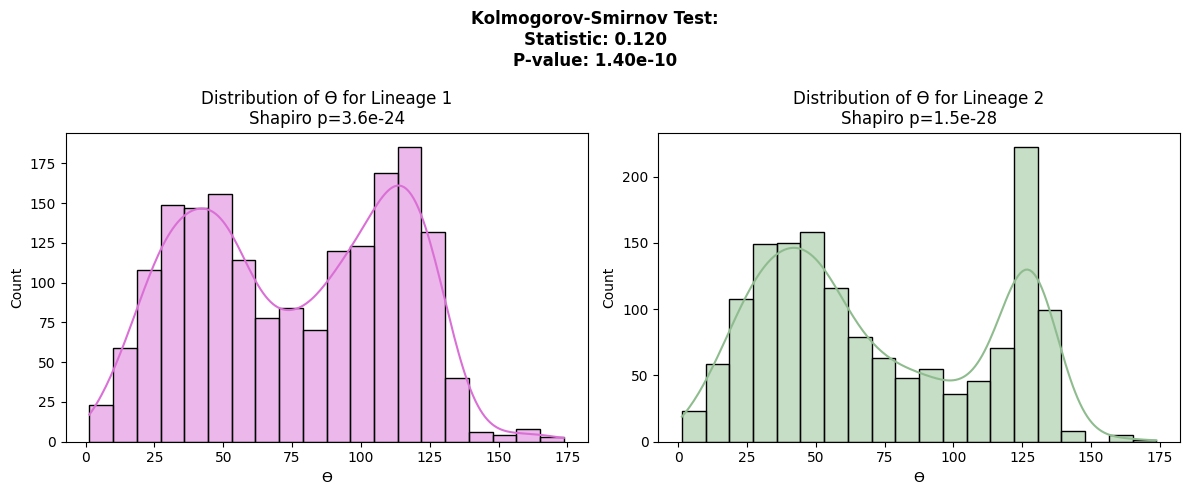

{'test_type': 'Kolmogorov-Smirnov Test',
 'test_statistic': 0.11957195190173421,
 'p_value': 1.3957357491989342e-10}

In [18]:
pc.statistical_test_on_lineages(  data, 
                                  lineage1=['neural progenitors', 'ChAT neurons 1', 'ChAT neurons 2'], 
                                  lineage2=['neural progenitors', 'cav-1+ neurons', 'GABA neurons'], 
                                  pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                                  cluster_column='celltype', 
                                  figsize=(12, 5))

In [19]:
cell_types_of_interest = ['phagocytes', 'glia',  'muscle pharynx', 'epidermis', 'ChAT neurons 2', 'GABA neurons']
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

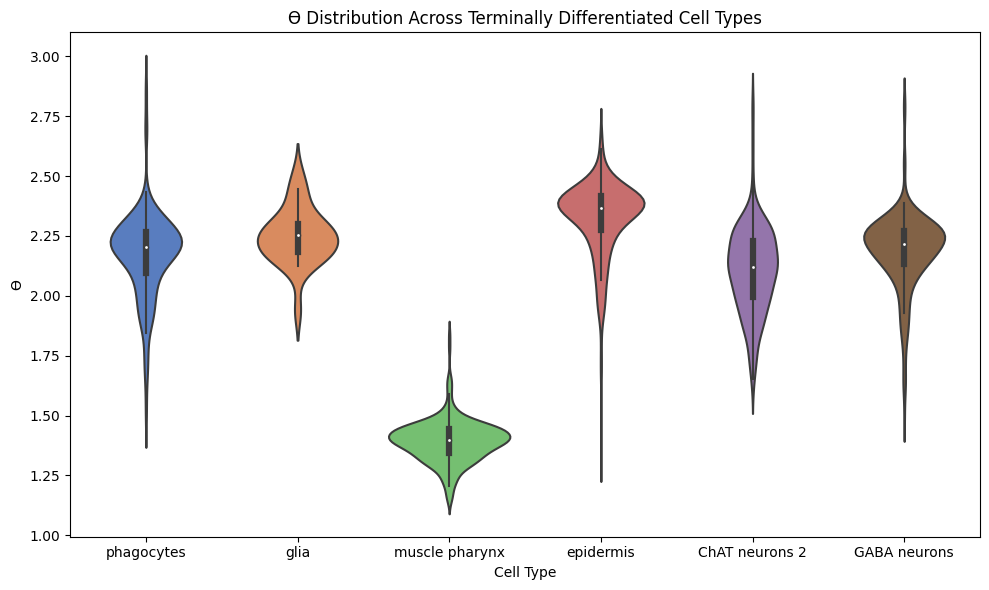

In [20]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='celltype', y='theta', data=filtered_data, palette='muted')

plt.xlabel('Cell Type')
plt.ylabel('ϴ')
plt.title('ϴ Distribution Across Terminally Differentiated Cell Types')
plt.xticks()
plt.tight_layout()
plt.show()

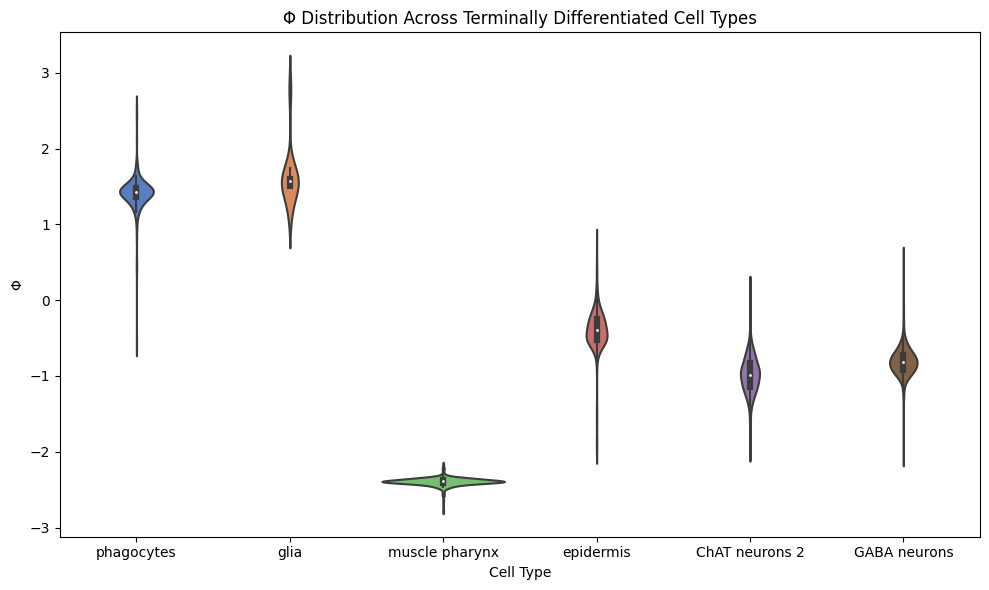

In [21]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='celltype', y='phi', data=filtered_data, palette='muted')

plt.xlabel('Cell Type')
plt.ylabel('Φ')
plt.title('Φ Distribution Across Terminally Differentiated Cell Types')
plt.xticks()
plt.tight_layout()
plt.show()